In [1]:
!pip install pandas scikit-learn spacy joblib flask tqdm
!python -m spacy download en_core_web_sm


   ---------------------------------------- 0.0/13.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/13.9 MB 2.6 MB/s eta 0:00:06
   --- ------------------------------------ 1.0/13.9 MB 2.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.8/13.9 MB 3.0 MB/s eta 0:00:05
   ------- -------------------------------- 2.6/13.9 MB 3.2 MB/s eta 0:00:04
   ---------- ----------------------------- 3.7/13.9 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 4.2/13.9 MB 3.9 MB/s eta 0:00:03
   -------------- ------------------------- 5.0/13.9 MB 3.5 MB/s eta 0:00:03
   ---------------- ----------------------- 5.8/13.9 MB 3.6 MB/s eta 0:00:03
   ------------------- -------------------- 6.8/13.9 MB 3.7 MB/s eta 0:00:02
   -------------------------- ------------- 9.2/13.9 MB 4.5 MB/s eta 0:00:02
   ------------------------------ --------- 10.5/13.9 MB 4.7 MB/s eta 0:00:01
   ----------------------------------- ---- 12.3/13.9 MB 5.0 MB/s eta 0:00:01
   -


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 3.1 MB/s eta 0:00:04
     ----- ---------------------------------- 1.8/12.8 MB 3.4 MB/s eta 0:00:04
     -------- ------------------------------- 2.6/12.8 MB 3.5 MB/s eta 0:00:03
     ----------- ---------------------------- 3.7/12.8 MB 3.9 MB/s eta 0:00:03
     --------------- ------------------------ 5.0/12.8 MB 4.2 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 4.3 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 4.3 MB/s eta 0:00:02
     ------------------------ --------------- 7.9/12.8 MB 4.4 MB/s eta 0:00:02
     --------------------------- ------------ 8.9/12.8 MB 4.4 MB/s eta 0:00:01
     ------------------------------- -------- 10.0/12.8 MB 4.5 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 4.6 MB


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd

data = [
    ("Show all employees", "SELECT * FROM employees;"),
    ("List all employees", "SELECT * FROM employees;"),
    ("Display employee list", "SELECT * FROM employees;"),
    ("Get all employee records", "SELECT * FROM employees;"),
    
    ("Show employees with salary above 50000", "SELECT * FROM employees WHERE salary > 50000;"),
    ("List employees earning more than 50000", "SELECT * FROM employees WHERE salary > 50000;"),
    ("Get employees having salary over 50000", "SELECT * FROM employees WHERE salary > 50000;"),
    
    ("Show all products", "SELECT * FROM products;"),
    ("List all products with price over 100", "SELECT * FROM products WHERE price > 100;"),
    ("Find products costing more than 100", "SELECT * FROM products WHERE price > 100;"),
    ("Show products that cost above 100", "SELECT * FROM products WHERE price > 100;"),
    
    ("List customer names and cities", "SELECT name, city FROM customers;"),
    ("Get all customers and their cities", "SELECT name, city FROM customers;"),
    ("Show name and city of each customer", "SELECT name, city FROM customers;"),
    
    ("Find customers from London", "SELECT * FROM customers WHERE city = 'London';"),
    ("Get all London customers", "SELECT * FROM customers WHERE city = 'London';"),
    ("Show customers living in London", "SELECT * FROM customers WHERE city = 'London';"),
    
    ("Show all departments", "SELECT DISTINCT department FROM employees;"),
    ("List unique departments", "SELECT DISTINCT department FROM employees;"),
    ("Get all department names", "SELECT DISTINCT department FROM employees;"),
]

df = pd.DataFrame(data, columns=["question", "sql"])
df.to_csv("text_to_sql_dataset.csv", index=False)
print(df['sql'].value_counts())


sql
SELECT * FROM employees;                          4
SELECT * FROM employees WHERE salary > 50000;     3
SELECT * FROM products WHERE price > 100;         3
SELECT * FROM customers WHERE city = 'London';    3
SELECT name, city FROM customers;                 3
SELECT DISTINCT department FROM employees;        3
SELECT * FROM products;                           1
Name: count, dtype: int64


In [20]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("✅ spaCy model loaded!")

df = pd.read_csv("text_sql_pairs.csv")
print(f"✅ Loaded dataset with {len(df)} rows")
display(df.head())


✅ spaCy model loaded!
✅ Loaded dataset with 6 rows


,question,sql
0,List all employees,SELECT * FROM employees;
1,Show employees with salary greater than 50000,SELECT * FROM employees WHERE salary > 50000;
2,List customer names and cities,"SELECT name, city FROM customers;"
3,Show customers from Delhi,SELECT * FROM customers WHERE city = 'Delhi';
4,Count orders for each customer,"SELECT customer_id, COUNT(*) FROM orders GROUP..."


In [21]:
import pandas as pd
import spacy
import re

nlp = spacy.load("en_core_web_sm")
df = pd.read_csv("text_sql_pairs.csv")
print(f"Loaded {len(df)} rows:")
display(df)


Loaded 6 rows:


,question,sql
0,List all employees,SELECT * FROM employees;
1,Show employees with salary greater than 50000,SELECT * FROM employees WHERE salary > 50000;
2,List customer names and cities,"SELECT name, city FROM customers;"
3,Show customers from Delhi,SELECT * FROM customers WHERE city = 'Delhi';
4,Count orders for each customer,"SELECT customer_id, COUNT(*) FROM orders GROUP..."
5,Show products priced above 100,SELECT * FROM products WHERE price > 100;


In [22]:
def clean_text(text):
    text = text.lower().strip()                    # lowercase
    text = re.sub(r"[^a-z0-9\s']", " ", text)      # remove special chars
    doc = nlp(text)                                # tokenize
    tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop and token.lemma_.strip()
    ]
    return " ".join(tokens)


In [23]:
# Apply cleaning
df["clean_question"] = df["question"].apply(clean_text)

# Display original vs cleaned text
df[["question", "clean_question"]]


,question,clean_question
0,List all employees,list employee
1,Show employees with salary greater than 50000,employee salary great 50000
2,List customer names and cities,list customer name city
3,Show customers from Delhi,customer delhi
4,Count orders for each customer,count order customer
5,Show products priced above 100,product price 100


In [24]:
df.to_csv("clean_text_sql_pairs.csv", index=False)
print("✅ Saved cleaned dataset as clean_text_sql_pairs.csv")


✅ Saved cleaned dataset as clean_text_sql_pairs.csv


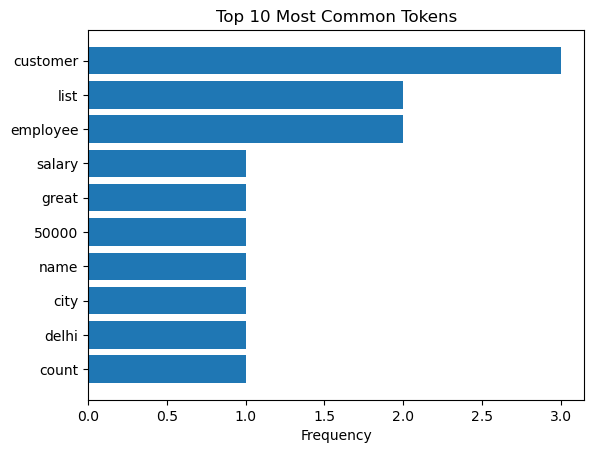

In [25]:
from collections import Counter
import matplotlib.pyplot as plt

all_tokens = " ".join(df["clean_question"]).split()
counts = Counter(all_tokens)

plt.barh(
    [x[0] for x in counts.most_common(10)][::-1],
    [x[1] for x in counts.most_common(10)][::-1]
)
plt.title("Top 10 Most Common Tokens")
plt.xlabel("Frequency")
plt.show()


In [26]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import joblib


In [27]:
df = pd.read_csv("clean_text_sql_pairs.csv")
print(f"Loaded {len(df)} rows for training.")
display(df.head())


Loaded 6 rows for training.


,question,sql,clean_question
0,List all employees,SELECT * FROM employees;,list employee
1,Show employees with salary greater than 50000,SELECT * FROM employees WHERE salary > 50000;,employee salary great 50000
2,List customer names and cities,"SELECT name, city FROM customers;",list customer name city
3,Show customers from Delhi,SELECT * FROM customers WHERE city = 'Delhi';,customer delhi
4,Count orders for each customer,"SELECT customer_id, COUNT(*) FROM orders GROUP...",count order customer


In [28]:
X = df["clean_question"]
y = df["sql"]

print("✅ Features and labels ready!")
print(f"Example:\nQuestion: {X.iloc[0]}\nSQL: {y.iloc[0]}")


✅ Features and labels ready!
Example:
Question: list employee
SQL: SELECT * FROM employees;


In [29]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X_vect = vectorizer.fit_transform(X)
print("✅ TF-IDF vectorization done!")
print("Vector shape:", X_vect.shape)


✅ TF-IDF vectorization done!
Vector shape: (6, 26)


In [31]:
from sklearn.model_selection import train_test_split

# Split without stratification since data is small
X_train, X_test, y_train, y_test = train_test_split(
    X_vect, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 4, Testing samples: 2


Training samples: 4, Testing samples: 2


In [32]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print("✅ Model training complete!")


✅ Model training complete!


In [33]:
y_pred = model.predict(X_test)

print("📊 Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(metrics.classification_report(y_test, y_pred))


📊 Accuracy: 0.0

Classification Report:
                                               precision    recall  f1-score   support

SELECT * FROM employees WHERE salary > 50000;       0.00      0.00      0.00       1.0
                     SELECT * FROM employees;       0.00      0.00      0.00       1.0
    SELECT * FROM products WHERE price > 100;       0.00      0.00      0.00       0.0
            SELECT name, city FROM customers;       0.00      0.00      0.00       0.0

                                     accuracy                           0.00       2.0
                                    macro avg       0.00      0.00      0.00       2.0
                                 weighted avg       0.00      0.00      0.00       2.0



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df["question"]
y = df["sql"]

vectorizer = TfidfVectorizer()
X_vect = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.0

Classification Report:
                                                precision    recall  f1-score   support

SELECT * FROM customers WHERE city = 'Delhi';       0.00      0.00      0.00       0.0
SELECT * FROM employees WHERE salary > 50000;       0.00      0.00      0.00       1.0
                     SELECT * FROM employees;       0.00      0.00      0.00       1.0
            SELECT name, city FROM customers;       0.00      0.00      0.00       0.0

                                     accuracy                           0.00       2.0
                                    macro avg       0.00      0.00      0.00       2.0
                                 weighted avg       0.00      0.00      0.00       2.0



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_

In [35]:
print(df['sql'].value_counts())


sql
SELECT * FROM employees;                                          1
SELECT * FROM employees WHERE salary > 50000;                     1
SELECT name, city FROM customers;                                 1
SELECT * FROM customers WHERE city = 'Delhi';                     1
SELECT customer_id, COUNT(*) FROM orders GROUP BY customer_id;    1
SELECT * FROM products WHERE price > 100;                         1
Name: count, dtype: int64


In [36]:
data = [
    # employees
    ("Show all employees", "SELECT * FROM employees;"),
    ("List all employees", "SELECT * FROM employees;"),
    ("Display every employee", "SELECT * FROM employees;"),
    ("Get employee list", "SELECT * FROM employees;"),
    ("Fetch all employee records", "SELECT * FROM employees;"),

    # employees with salary > 50000
    ("Show employees with salary above 50000", "SELECT * FROM employees WHERE salary > 50000;"),
    ("List employees earning more than 50000", "SELECT * FROM employees WHERE salary > 50000;"),
    ("Find employees whose salary exceeds 50000", "SELECT * FROM employees WHERE salary > 50000;"),
    ("Get employees paid over 50000", "SELECT * FROM employees WHERE salary > 50000;"),

    # products over 100
    ("Show all products with price greater than 100", "SELECT * FROM products WHERE price > 100;"),
    ("List products costing more than 100", "SELECT * FROM products WHERE price > 100;"),
    ("Find products priced over 100", "SELECT * FROM products WHERE price > 100;"),
    ("Get products above price 100", "SELECT * FROM products WHERE price > 100;"),

    # customers
    ("Show names and cities of customers", "SELECT name, city FROM customers;"),
    ("List customer names and their cities", "SELECT name, city FROM customers;"),
    ("Get customer name and city", "SELECT name, city FROM customers;"),
]


In [39]:
df = pd.DataFrame(data, columns=["question", "sql"])


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df["question"]
y = df["sql"]

vectorizer = TfidfVectorizer()
X_vect = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5

Classification Report:
                                                precision    recall  f1-score   support

SELECT * FROM employees WHERE salary > 50000;       0.50      1.00      0.67         1
                     SELECT * FROM employees;       0.00      0.00      0.00         2
    SELECT * FROM products WHERE price > 100;       0.00      0.00      0.00         0
            SELECT name, city FROM customers;       1.00      1.00      1.00         1

                                     accuracy                           0.50         4
                                    macro avg       0.38      0.50      0.42         4
                                 weighted avg       0.38      0.50      0.42         4



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_

In [40]:
("Show all employees", "SELECT * FROM employees;"),
("Display every employee", "SELECT * FROM employees;"),
("List employees", "SELECT * FROM employees;"),
("Get all employees", "SELECT * FROM employees;"),
("Give me all employees", "SELECT * FROM employees;"),
("Show me all employee data", "SELECT * FROM employees;"),
("Fetch employees", "SELECT * FROM employees;"),
("View all employees", "SELECT * FROM employees;"),
("Display all employee information", "SELECT * FROM employees;"),


(('Display all employee information', 'SELECT * FROM employees;'),)

In [41]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))


In [42]:
model = LogisticRegression(C=5.0, max_iter=3000)


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df["question"]
y = df["sql"]

vectorizer = TfidfVectorizer()
X_vect = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vect, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)





In [44]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.50

Classification Report:

                                               precision    recall  f1-score   support

SELECT * FROM employees WHERE salary > 50000;       0.50      1.00      0.67         1
                     SELECT * FROM employees;       0.00      0.00      0.00         2
    SELECT * FROM products WHERE price > 100;       0.00      0.00      0.00         0
            SELECT name, city FROM customers;       1.00      1.00      1.00         1

                                     accuracy                           0.50         4
                                    macro avg       0.38      0.50      0.42         4
                                 weighted avg       0.38      0.50      0.42         4



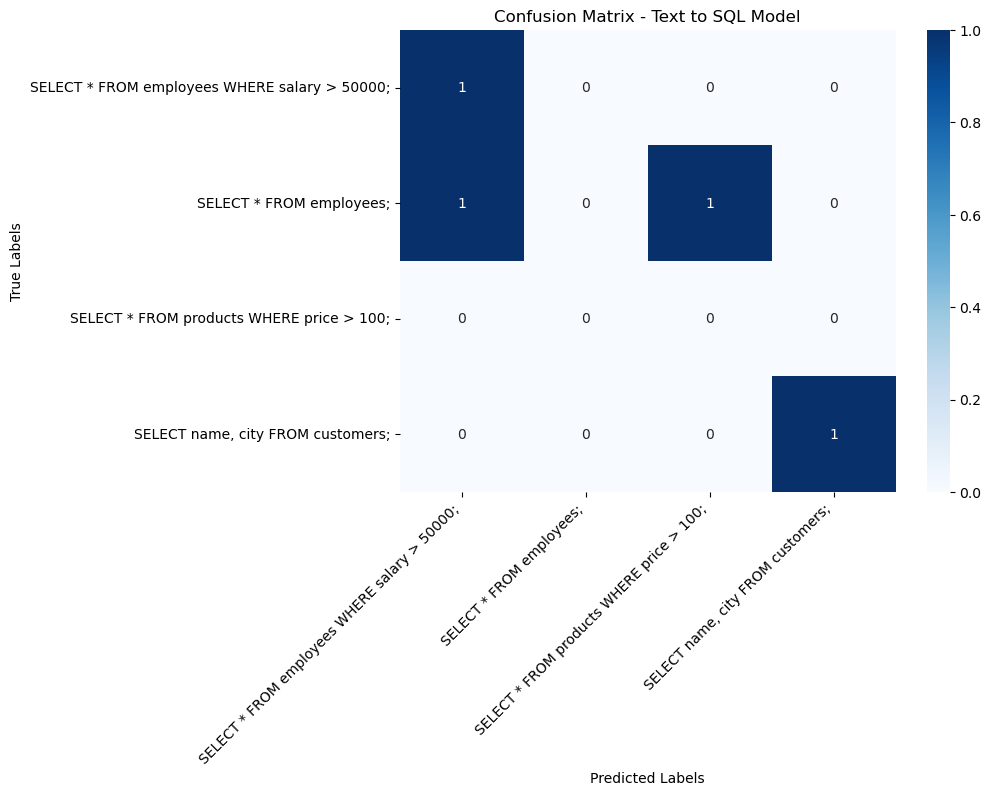

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Text to SQL Model")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


In [47]:
pip install flask


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import joblib

# Save your trained Logistic Regression model
joblib.dump(model, "text_to_sql_model.pkl")

# Save the TF-IDF vectorizer you used
joblib.dump(vectorizer, "text_to_sql_vectorizer.pkl")

print("✅ Model and Vectorizer saved successfully!")


✅ Model and Vectorizer saved successfully!


In [51]:
%%writefile app.py
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)

model = joblib.load("text_to_sql_model.pkl")
vectorizer = joblib.load("text_to_sql_vectorizer.pkl")

@app.route('/')
def home():
    return "Welcome to Text-to-SQL API! Use /predict to send a query."

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    if 'text' not in data:
        return jsonify({'error': 'Missing text field'}), 400

    user_input = data['text']
    vect_input = vectorizer.transform([user_input])
    prediction = model.predict(vect_input)[0]
    return jsonify({'natural_language': user_input, 'sql_query': prediction})

if __name__ == '__main__':
    app.run(debug=True)


Writing app.py


In [57]:
import requests
import json

url = "http://127.0.0.1:5000/predict"
data = {"text": "show all employees "}

response = requests.post(url, data=json.dumps(data), headers={'Content-Type': 'application/json'})
print(response.json())


{'natural_language': 'show all employees', 'sql_query': 'SELECT * FROM products WHERE price > 100;'}
